In [227]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
import matplotlib.pyplot as plt

In [228]:
np.random.seed(42)
tf.random.set_seed(42)

In [229]:
df = pd.read_csv("../data/processed/plays_processed_kmeans.csv")
df.head()

,quarter,down,yardsToGo,preSnapHomeScore,preSnapVisitorScore,absoluteYardlineNumber,timeToThrow,timeInTackleBox,passLength,urgencyScore,...,secondsElapsedTotal,yardsGained,playStyleCluster_0,playStyleCluster_1,playStyleCluster_2,playStyleCluster_3,playStyleCluster_4,playStyleCluster_5,playStyleCluster_6,playStyleCluster_7
0,3.0,1.0,0.393677,2.507782,0.753479,-1.209175,0.969961,1.062836,0.224264,-0.421079,...,0.656919,9.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,4.0,1.0,0.393677,0.606681,0.753479,-1.743599,0.227520,0.263292,-0.015304,-0.421079,...,1.482502,4.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,4.0,3.0,0.905377,-0.871954,0.753479,-1.250285,0.484865,0.540431,-0.973572,2.270531,...,1.494684,6.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,1.0,2.0,0.393677,-1.188804,-1.089461,-1.126956,0.462991,0.516874,-1.213139,0.614155,...,-1.455301,4.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,3.0,2.0,-0.118024,-0.132637,-0.005379,-0.962518,-0.953696,-1.008771,-0.494438,0.200061,...,0.636303,-1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [230]:
X = df.drop('yardsGained', axis=1)
Y = df.yardsGained

In [231]:
_X_train, X_test, _Y_train, Y_test = train_test_split(X, Y, train_size=0.8, shuffle=True, random_state=42)
X_train, X_val, Y_train, Y_val = train_test_split(_X_train, _Y_train, train_size=0.75, shuffle=True, random_state=42)

print("X_train", X_train.shape)
print("Y_train", Y_train.shape)

print("X_val", X_val.shape)
print("Y_val", Y_val.shape)

print("X_test", X_test.shape)
print("Y_test", Y_test.shape)

X_train (9674, 24)
Y_train (9674,)
X_val (3225, 24)
Y_val (3225,)
X_test (3225, 24)
Y_test (3225,)


In [232]:
def build_model(hidden_layer_sizes=[],
                activation='relu',
                optimizer='Adam',
                learning_rate=0.01,
                dropout_rate=0.0,
                use_batchnorm=False):
    tf.keras.backend.clear_session()

    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(24,), name='input'))

    for i, units in enumerate(hidden_layer_sizes):
        model.add(tf.keras.layers.Dense(units, activation=None, name=f'hidden_layer_{i+1}'))
        if use_batchnorm:
            model.add(tf.keras.layers.BatchNormalization())
        model.add(tf.keras.layers.Activation(activation))
        if dropout_rate > 0:
            model.add(tf.keras.layers.Dropout(dropout_rate))

    model.add(tf.keras.layers.Dense(1, activation=None, name='output'))

    if optimizer == 'SGD':
        opt = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    elif optimizer == 'Adam':
        opt = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    else:
        print(f'Invalid optimizer: {optimizer}')
        return None

    model.compile(
        optimizer=opt,
        loss='mse',
        metrics=[tf.keras.metrics.RootMeanSquaredError(name='rmse'),
                 tf.keras.metrics.MeanAbsoluteError(name='mae')]
    )

    return model

In [233]:
model = build_model([64, 64], optimizer='SGD', learning_rate=0.0005, dropout_rate=0.2, use_batchnorm=True)

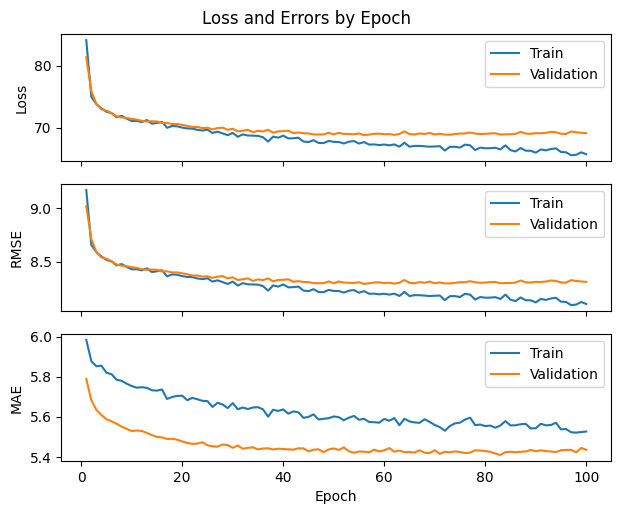

In [234]:
def fit_and_plot_model(model_):

    fitting_history = model_.fit(
        x=X_train,
        y=Y_train,
        epochs=100,
        batch_size=64,
        validation_data=(X_val, Y_val),
        verbose=0
    )

    # # 4. Generate (1,3) plot
    fig, axes = plt.subplots(3, 1, sharex=True)

    # Plot losses by epoch
    losses = fitting_history.history.get('loss')
    val_losses = fitting_history.history.get('val_loss')

    axes[0].plot(range(1, len(losses) + 1), losses, label='Train')
    axes[0].plot(range(1, len(val_losses) + 1), val_losses, label='Validation')
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    # Plot RMSE by epoch
    rmse = fitting_history.history.get('rmse')
    val_rsme = fitting_history.history.get('val_rmse')

    axes[1].plot(range(1, len(rmse) + 1), rmse, label='Train')
    axes[1].plot(range(1, len(val_rsme) + 1), val_rsme, label='Validation')
    axes[1].set_ylabel("RMSE")
    axes[1].legend()

    # Plot MAE by epoch
    mae = fitting_history.history.get('mae')
    val_mae = fitting_history.history.get('val_mae')

    axes[2].plot(range(1, len(rmse) + 1), mae, label='Train')
    axes[2].plot(range(1, len(val_mae) + 1), val_mae, label='Validation')
    axes[2].set_ylabel("MAE")
    axes[2].legend()

    # General figure settings
    fig.tight_layout()
    fig.suptitle("Loss and Errors by Epoch", y=1.02)
    axes[-1].set_xlabel('Epoch')
    plt.legend()
    plt.show()

fit_and_plot_model(model)

In [235]:
results = model.evaluate(X_test, Y_test, verbose=0)

print(f"Test Loss (MSE): {results[0]:.4f}")
print(f"Test RMSE: {results[1]:.4f}")
print(f"Test MAE: {results[2]:.4f}")

Test Loss (MSE): 66.5248
Test RMSE: 8.1563
Test MAE: 5.4419
